 Library Setup & Dataset Loading

.


## 1. Environment Check

Confirm the notebook is running inside the project's virtual environment (`venv`).

In [1]:
import sys
print(sys.executable)

c:\Users\Fast Computer\Desktop\multi-layer-project\venv\Scripts\python.exe


## 2. Library Installation

In [2]:
import nltk
import spacy
import cv2
import torchvision
import transformers
import datasets

print("✅ All libraries imported successfully!")

c:\Users\Fast Computer\Desktop\multi-layer-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


In [3]:
print("NLTK:", nltk.__version__)
print("spaCy:", spacy.__version__)
print("OpenCV:", cv2.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

NLTK: 3.10.0
spaCy: 3.8.14
OpenCV: 5.0.0
Torchvision: 0.28.0+cpu
Transformers: 5.13.0
Datasets: 5.0.0


## 3. NLTK Test

Tokenizing a simple sentence to confirm NLTK's `punkt` tokenizer works.

In [4]:
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

print(word_tokenize("A dog runs across the field."))

[nltk_data] Error loading punkt: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading punkt_tab: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>


['A', 'dog', 'runs', 'across', 'the', 'field', '.']


## 4. spaCy Test

Running the small English pipeline (`en_core_web_sm`) to confirm tokenization and POS tagging work.

In [5]:
nlp = spacy.load("en_core_web_sm")

doc = nlp("Flickr8k is an image captioning dataset.")

for token in doc:
    print(token.text, token.pos_)

Flickr8k NOUN
is AUX
an DET
image NOUN
captioning ADJ
dataset NOUN
. PUNCT


## 5. OpenCV Test

Reading a sample image from the Flickr8k dataset and confirming it loads as an array with the expected shape `(height, width, channels)`.

In [6]:
img = cv2.imread("../data/flickr8k/Images/1000268201_693b08cb0e.jpg")

print("Image shape:", img.shape)

Image shape: (500, 375, 3)


## 6. torchvision Test

Confirming torchvision is installed and importable.

In [7]:
print("Torchvision version:", torchvision.__version__)

Torchvision version: 0.28.0+cpu


## 7. Hugging Face Transformers Test

In [8]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

print(classifier("I love machine learning"))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2328.73it/s]
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english/resolve/714eb0f/processor_config.json
Retrying in 1s [Retry 1/5].


[{'label': 'POSITIVE', 'score': 0.9997808337211609}]


## 8. Flickr8k Dataset — Load & Preview

Loading the captions file and confirming the dataset is accessible from this notebook.

In [9]:
import os
import pandas as pd

image_folder = "../data/flickr8k/Images"
captions_path = "../data/flickr8k/captions.txt"

captions = pd.read_csv(captions_path)
captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


### Sample Image Preview

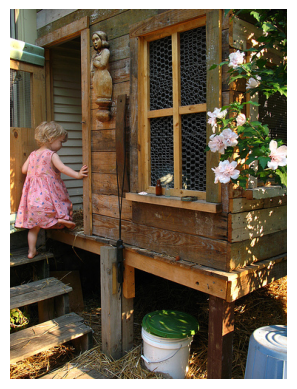

In [10]:
import matplotlib.pyplot as plt

img_path = os.path.join(image_folder, os.listdir(image_folder)[0])

img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

### Dataset Summary

In [11]:
print("Total caption rows:", len(captions))
print("Unique images:", captions["image"].nunique())

Total caption rows: 40455
Unique images: 8091


## Summary

- All Day 3 libraries installed and tested (NLTK, spaCy, Transformers, Datasets, OpenCV, torchvision)
- Flickr8k dataset successfully loaded and previewed
- requirements.txt` committed to repo root
